## Волновое уравнение

Одномерное волновое уравнение для малых поперечных колебаний струны:

$$
\frac{\partial^2 u}{\partial t^2} = c^2 \cdot \frac{\partial^2 u}{\partial x^2}
$$

где:
- $u = u(x,t)$ - искомая функция (отклонение струны) 
- $x$ - пространственная координата 
- $t$ - время 
- $c$ - скорость распространения волны

Подключаем библиотеки:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Треугольный профиль (щипок струны в центре):

In [11]:
def f(x, L):
    center = L / 2 
    width = L / 2
    height = 1.0 
    result = np.zeros_like(x)
    triang_left = (x >= center - width) & (x <= center)
    triang_right = (x > center) & (x <= center + width)
    result[triang_left] = height * (x[triang_left] - (center - width)) / width
    result[triang_right] = height * ((center + width) - x[triang_right]) / width
    return result

Синусоидальные моды для стоячих волн:

In [12]:
def sin_mode(x, L, n):
    return np.sin(n * np.pi * x / L)

Реализация явной схемы крест с разными граничными условиями:

In [13]:
def solve_wave_equation(L=1.0, c=1.0, T=2.0, nx=101, CFL=0.9, bc_type='fixed', initial_condition='triangle', mode_n=1):
    x = np.linspace(0, L, nx)
    dx = x[1] - x[0]
    dt = CFL * dx / c
    nt = int(T / dt) + 1
    t = np.linspace(0, T, nt)
    
    print(f"Параметры сетки:")
    print(f"dx = {dx:.4f}, dt = {dt:.4f}")
    print(f"CFL = {CFL:.2f}, Граничные условия: {bc_type}")
    print(f"Количество временных шагов: {nt}")
    
    # Начальные условия
    if initial_condition == 'triangle':
        u_curr = f(x, L)  # u(x, 0)
    elif initial_condition == 'sin_mode':
        u_curr = sin_mode(x, L, mode_n)  # стоячая волна
    
    u_prev = u_curr.copy() 
    u = np.zeros((nt, nx))
    u[0, :] = u_curr    
    r = (c * dt / dx) ** 2
    
    # Первый временной шаг
    u_next = np.zeros(nx)
    u_next[1:-1] = u_curr[1:-1] + 0.5 * r * (u_curr[2:] - 2*u_curr[1:-1] + u_curr[:-2])
     
    # Граничные условия для первого шага
    if bc_type == 'fixed':
        u_next[0] = 0
        u_next[-1] = 0
    elif bc_type == 'free':
        # Свободный конец: du/dx = 0
        u_next[0] = u_next[1]  
        u_next[-1] = u_next[-2] 
    
    u[1, :] = u_next
    u_prev, u_curr = u_curr, u_next
    
    for n in range(2, nt):
        u_next = np.zeros(nx)
        u_next[1:-1] = (2 * u_curr[1:-1] - u_prev[1:-1] + r * (u_curr[2:] - 2*u_curr[1:-1] + u_curr[:-2]))
        
        # Граничные условия
        if bc_type == 'fixed':
            u_next[0] = 0
            u_next[-1] = 0
        elif bc_type == 'free':
            u_next[0] = u_next[1]   # du/dx = 0
            u_next[-1] = u_next[-2] # du/dx = 0
        
        u[n, :] = u_next
        u_prev, u_curr = u_curr, u_next
        
    return x, t, u, dt, CFL

Функция, вычисляющая полную энергию системы:

In [26]:
def calculate_energy(u, t, x, c, dt):
    dx = x[1] - x[0]
    energy = np.zeros(len(t))

    interior_slice = slice(1, -1)
    x_interior = x[interior_slice]
    
    for i in range(len(t)):
        dudx = np.gradient(u[i, interior_slice], dx)
        potential_energy = (c * dudx)**2
        
        if i == 0:
            kinetic_energy = np.zeros_like(x_interior)
        elif i == len(t) - 1:
            dudt = (u[i, interior_slice] - u[i-1, interior_slice]) / dt
            kinetic_energy = dudt**2
        else:
            dudt = (u[i+1, interior_slice] - u[i-1, interior_slice]) / (2 * dt)
            kinetic_energy = dudt**2
        
        total_density = kinetic_energy + potential_energy
        energy[i] = np.trapezoid(total_density, x_interior)
    
    return energy

Визуализация колебаний струны с помощью анимации

In [ ]:
def create_animation(x, t, u, CFL, bc_type, save_gif=False):
    fig, ax = plt.subplots(figsize=(10, 6))
    line, = ax.plot(x, u[0, :], 'b-', linewidth=2)
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.set_title(f'Колебания струны (CFL = {CFL:.2f}, Граничные условия: {bc_type})')
    ax.grid(True)
    
    def animate(frame):
        line.set_ydata(u[frame, :])
        return line,
    
    anim = FuncAnimation(fig, animate, frames=min(100, len(t)), interval=50, blit=True)
    plt.tight_layout()
    plt.show()
    return anim

**Анализ сохранения энергии**

In [34]:
def analyze_energy_conservation():
    L, c, T = 1.0, 1.0, 1.0
    bc_types = ['fixed', 'free']
    
    plt.figure(figsize=(15, 10))
    
    for i, bc_type in enumerate(bc_types):
        x, t, u, dt, CFL = solve_wave_equation(L=L, c=c, T=T, nx=101, CFL=0.9, bc_type=bc_type, initial_condition='triangle')
        energy = calculate_energy(u, t, x, c, dt)
        
        plt.subplot(2, 3, i*3 + 1)
        for time_idx in [0, len(t)//4, len(t)//2, 3*len(t)//4, -1]:
            plt.plot(x, u[time_idx, :], label=f't = {t[time_idx]:.2f}')
        plt.title(f'Форма волны ({bc_type} ends)')
        plt.xlabel('x')
        plt.ylabel('u(x,t)')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(2, 3, i*3 + 2)
        plt.plot(t, energy, 'r-', linewidth=2)
        plt.title(f'Полная энергия E(t) ({bc_type} ends)')
        plt.xlabel('Время t')
        plt.ylabel('Энергия E(t)')
        plt.grid(True)
        
        plt.subplot(2, 3, i*3 + 3)
        if energy[0] > 1e-10: 
            relative_energy_change = (energy - energy[0]) / energy[0]
        else:
            relative_energy_change = np.zeros_like(energy)
        plt.plot(t, relative_energy_change, 'g-', linewidth=2)
        plt.title(f'Относительное изменение энергии ({bc_type} ends)')
        plt.xlabel('Время t')
        plt.ylabel('(E(t) - E(0)) / E(0)')
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

Параметры сетки:
dx = 0.0100, dt = 0.0090
CFL = 0.90, Граничные условия: fixed
Количество временных шагов: 112
Параметры сетки:
dx = 0.0100, dt = 0.0090
CFL = 0.90, Граничные условия: free
Количество временных шагов: 112


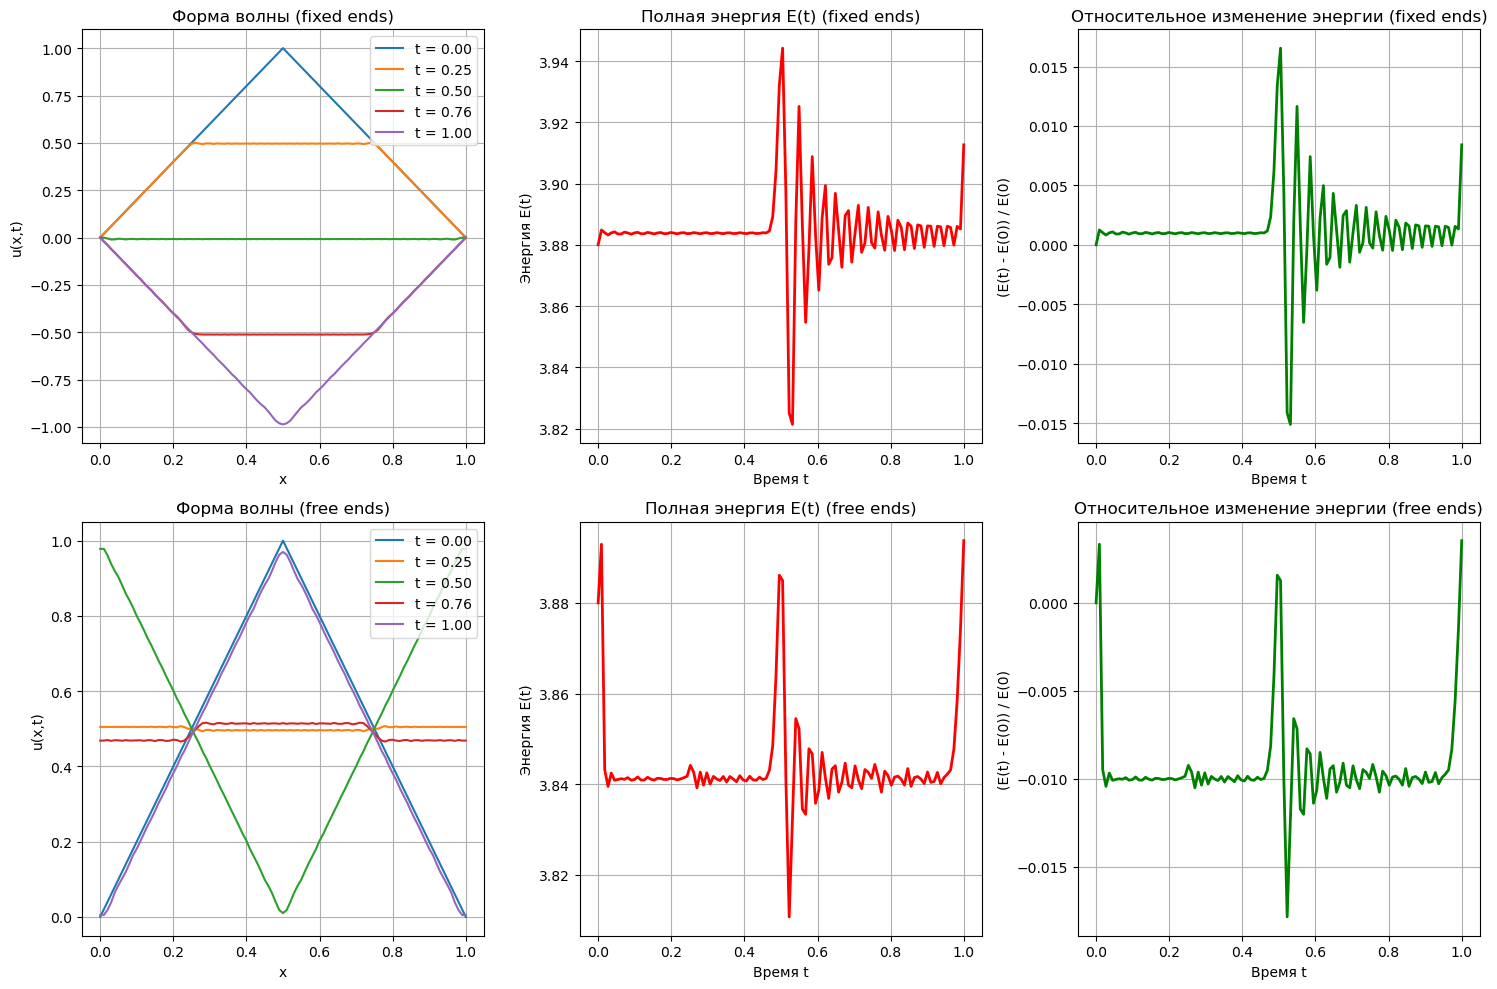

In [35]:
analyze_energy_conservation()

**Исследование стоячих волн**

In [39]:
def analyze_standing_waves():
    L, c, T = 1.0, 1.0, 1.0
    modes = [1, 2, 3] 
    plt.figure(figsize=(15, 5))
    for i, n in enumerate(modes):
        x, t, u, dt, CFL = solve_wave_equation(L=L, c=c, T=T, nx=101, CFL=0.9, bc_type='fixed', initial_condition='sin_mode', mode_n=n)
        plt.subplot(1, 3, i+1)
        for time_idx in [0, len(t)//4, len(t)//2, 3*len(t)//4, -1]:
            plt.plot(x, u[time_idx, :], label=f't = {t[time_idx]:.2f}')
        plt.title(f'Стоячая волна: sin({n}πx/L)')
        plt.xlabel('x')
        plt.ylabel('u(x,t)')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

Параметры сетки:
dx = 0.0100, dt = 0.0090
CFL = 0.90, Граничные условия: fixed
Количество временных шагов: 112
Параметры сетки:
dx = 0.0100, dt = 0.0090
CFL = 0.90, Граничные условия: fixed
Количество временных шагов: 112
Параметры сетки:
dx = 0.0100, dt = 0.0090
CFL = 0.90, Граничные условия: fixed
Количество временных шагов: 112


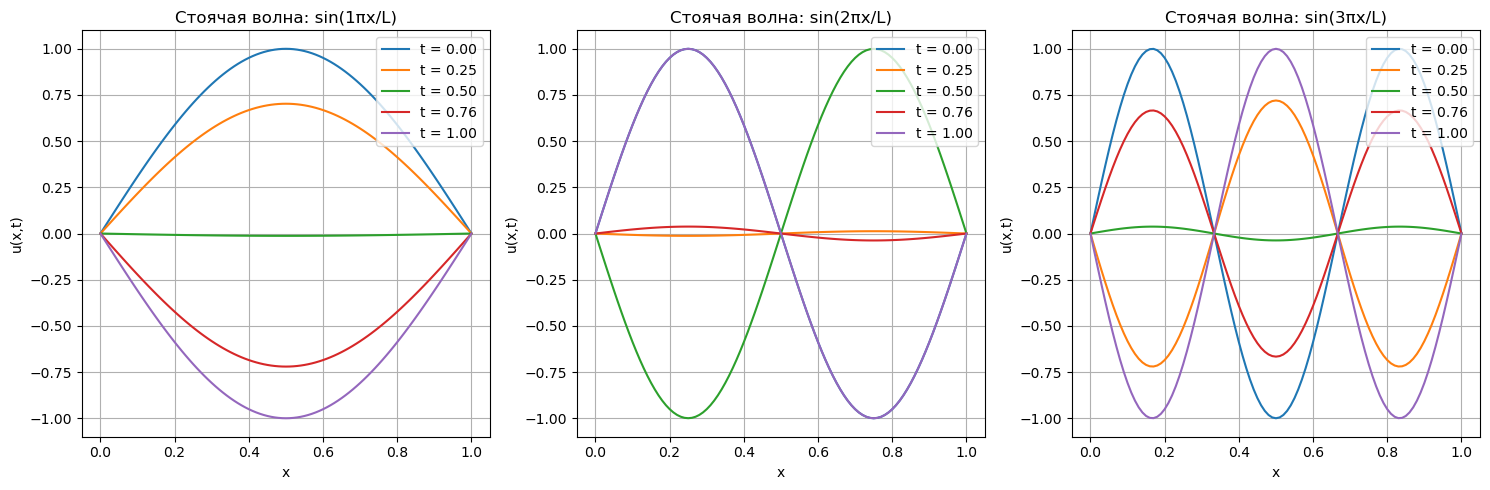

In [40]:
analyze_standing_waves()

**Анализ отражения волны при разных граничных условиях**

In [43]:
def analyze_wave_reflection():
    L, c, T = 1.0, 1.0, 1.0
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    for bc_type, ax in zip(['fixed', 'free'], [ax1, ax2]):
        x, t, u, dt, CFL = solve_wave_equation(L=L, c=c, T=T, nx=101, CFL=0.9, bc_type=bc_type, initial_condition='triangle')
        time_indices = [0, len(t)//6, len(t)//3, len(t)//2, 2*len(t)//3, 5*len(t)//6, -1]
        for idx in time_indices:
            ax.plot(x, u[idx, :], label=f't = {t[idx]:.2f}')
        ax.set_title(f'Отражение волны ({bc_type} end)')
        ax.set_xlabel('x')
        ax.set_ylabel('u(x,t)')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()

Параметры сетки:
dx = 0.0100, dt = 0.0090
CFL = 0.90, Граничные условия: fixed
Количество временных шагов: 112
Параметры сетки:
dx = 0.0100, dt = 0.0090
CFL = 0.90, Граничные условия: free
Количество временных шагов: 112


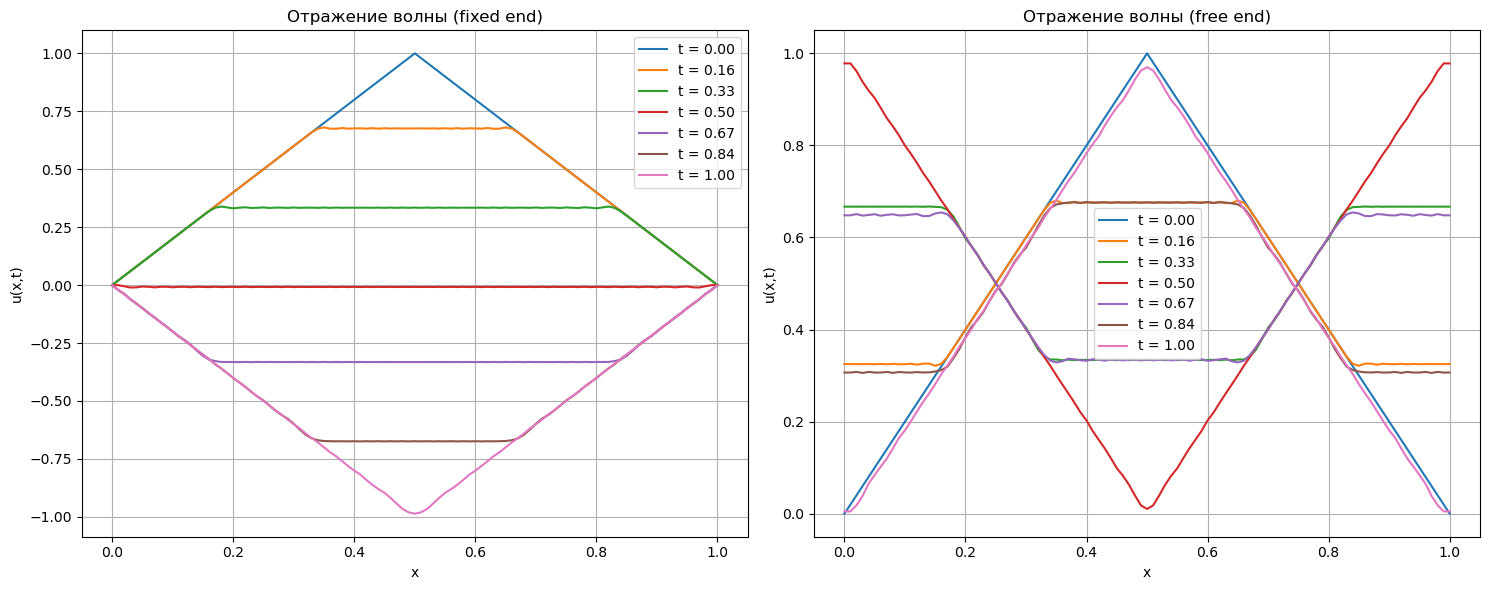

In [44]:
analyze_wave_reflection()